<a href="https://colab.research.google.com/github/kjfcvx12/Colab/blob/main/04_20_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# EfficientNet : 이미지 분류 모델 계열
# EfficientNet-B0, B4 등
!pip install -q validators

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 1.7 MB/s eta 0:00:00


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.transforms import transforms

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [3]:
# ImageNet 데이터셋으로 사전 학습된 모델 가져오기
efficient_net=torch.hub.load(
    'NVIDIA/DeepLearningExamples:torchhub',
    'nvidia_efficientnet_b0',
    pretrained=True
)
# 모델의 파라미터 gpu로 이동시킴
efficient_net.eval().to(device)

/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/NVIDIA/DeepLearningExamples/zipball/torchhub" to /root/.cache/torch/hub/torchhub.zip


/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/common.py:13: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(
/root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub/PyTorch/Classification/ConvNets/image_classification/models/efficientnet.py:17: UserWarning: pytorch_quantization module not found, quantization will not be available
  warnings.warn(


Downloading: "https://api.ngc.nvidia.com/v2/models/nvidia/efficientnet_b0_pyt_amp/versions/20.12.0/files/nvidia_efficientnet-b0_210412.pth" to /root/.cache/torch/hub/checkpoints/nvidia_efficientnet-b0_210412.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 139MB/s]


EfficientNet(
  (stem): Sequential(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (activation): SiLU(inplace=True)
  )
  (layers): Sequential(
    (0): Sequential(
      (block0): MBConvBlock(
        (depsep): Sequential(
          (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (se): SequentialSqueezeAndExcitation(
          (squeeze): Linear(in_features=32, out_features=8, bias=True)
          (expand): Linear(in_features=8, out_features=32, bias=True)
          (activation): SiLU(inplace=True)
          (sigmoid): Sigmoid()
          (mul_a_quantizer): Identity()
          (mul_b_quantizer): Identity()
        )
      

In [4]:
# 유틸리티 로드(텐서변환, 정규화, 크기조정.....)
utils=torch.hub.load(
     'NVIDIA/DeepLearningExamples:torchhub',
     'nvidia_convnets_processing_utils'
)

Using cache found in /root/.cache/torch/hub/NVIDIA_DeepLearningExamples_torchhub


In [5]:
# NVIDIA Hub 모델 -> 속도향상 이점

In [6]:
uris=[
    'http://images.cocodataset.org/test-stuff2017/000000024309.jpg',
    'http://images.cocodataset.org/test-stuff2017/000000004954.jpg',
]
uris

['http://images.cocodataset.org/test-stuff2017/000000024309.jpg',
 'http://images.cocodataset.org/test-stuff2017/000000004954.jpg']

In [7]:
# efficientnet_b0가 요구하는 규격 -> 텐서로 변환
# 전처리된 2개 이미지 텐서를 하나로 묶어 배치를 만듬
batch=torch.cat([utils.prepare_input_from_uri(uri) for uri in uris]).to(device)
batch.shape
# [2, 3, 224, 224] : [batch_size, channel, 세로픽셀수, 가로픽셀수]

torch.Size([2, 3, 224, 224])

In [8]:
# 모델 예측결과 중 확률 높은 거 선택
# 모든 미분(경사값) 추적작업 중단

# 2장 이미지 담긴 텐서가 efficient_net 신경망 통과
# output 에는 1000개의 클래스에 대한 점수가 담겨져 있다.
with torch.inference_mode():
  output=torch.nn.functional.softmax(efficient_net(batch), dim=1)

# 1000개의 확률값 중 가장 높은 3개 뽑
result=utils.pick_n_best(predictions=output, n=3)

sample 0: [('laptop, laptop computer', '49.9%'), ('notebook, notebook computer', '36.2%'), ('desk', '3.7%')]
sample 1: [('kelpie', '52.7%'), ('malinois', '4.1%'), ('groenendael', '3.0%')]


In [9]:
import requests

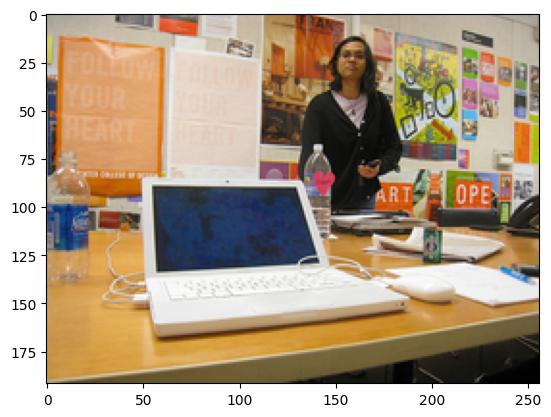

[('laptop, laptop computer', '49.9%'), ('notebook, notebook computer', '36.2%'), ('desk', '3.7%')]


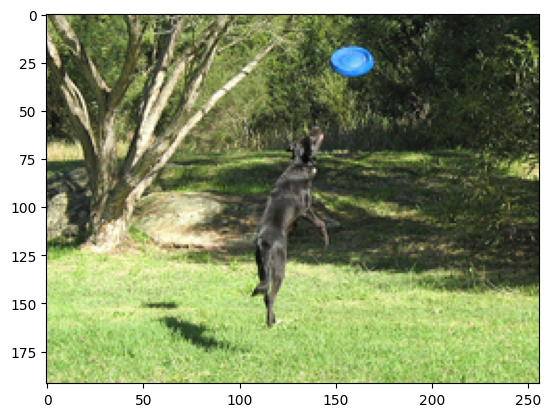

[('kelpie', '52.7%'), ('malinois', '4.1%'), ('groenendael', '3.0%')]


In [10]:
for uri, res in zip(uris, result):
  # raw: 가공되지 않은 바이너리 스트림 형태로 가져와서 Image이 읽을 수 있게 전달한다
  img=Image.open(requests.get(uri, stream=True).raw)
  # 256픽셀로 맞춰 줄임
  # 이미지 줄일 때 화질 최대 보존하는 고성능 필터명
  img.thumbnail((256,256), Image.Resampling.LANCZOS)
  plt.imshow(img)
  plt.show()
  print(res)